# 21_ensemble_cem_halfcheetah.ipynb — Phase 1 (Ensemble + CEM)
**Model-Based RL:** Ensemble Forward Models + CEM Planlayıcı  
Ortam (varsayılan): **InvertedDoublePendulum-v4** (MuJoCo, continuous)

Bu defter:
- **Veri toplama:** kısa PPO (10k) + gürültülü politika (100k) → geniş kapsama.
- **Ensemble:** 3–7 adet MLP (delta-state), ortalama ile toplulaştırma.
- **CEM planlayıcı:** horizon H∈[5, 20], aday 1000, elit frak. 0.1–0.2.
- **Ablation:** **ensemble size** (3/5/7) ve **planlama süresi** (ms/step) karşılaştırması.
- **Render:** Pygame ile CEM ve PPO demoları.
- **Klasör/TensorBoard:** `runs/Phase 1/21_ensemble_cem_halfcheetah/<RUN_ID>/...`

In [10]:
# %pip install -U gymnasium mujoco stable-baselines3 tensorboard pandas matplotlib tqdm pygame

## 1) Kütüphaneler & Bootstrap (aynı düzen)

In [11]:
import os, sys, time, uuid, json, random, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter

import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.logger import configure
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.utils import set_random_seed
from tensorboard.backend.event_processing import event_accumulator as ea

class RLBootstrap:
    def __init__(self, phase, notebook, step, env_id, seed=42):
        self.phase, self.notebook, self.step, self.env_id = phase, notebook, step, env_id
        self.seed = seed
        set_random_seed(seed); np.random.seed(seed); random.seed(seed)
        self.run_id   = time.strftime('%Y%m%d-%H%M%S') + f"-{uuid.uuid4().hex[:6]}"
        self.root_dir = os.path.join('runs', self.phase, self.notebook, self.run_id)
        self.ckpt_dir = os.path.join(self.root_dir, 'checkpoints')
        self.mon_dir  = os.path.join(self.root_dir, 'monitor')
        os.makedirs(self.ckpt_dir, exist_ok=True); os.makedirs(self.mon_dir, exist_ok=True)
        self._write_meta()
    def algo_dir(self, algo_name):
        safe_env = self.env_id.replace('-', '_')
        d = os.path.join(self.root_dir, f"{algo_name}_{safe_env}")
        os.makedirs(d, exist_ok=True)
        return d
    def make_env(self, render=False, monitor=True):
        env = gym.make(self.env_id, render_mode='human') if render else gym.make(self.env_id)
        if monitor:
            md = os.path.join(self.mon_dir, self.env_id.replace('-', '_'))
            os.makedirs(md, exist_ok=True)
            env = Monitor(env, md)
        return env
    def _write_meta(self):
        m = dict(phase=self.phase, notebook=self.notebook, step=self.step, env=self.env_id,
                 seed=self.seed, run_id=self.run_id, root_dir=self.root_dir,
                 ckpt_dir=self.ckpt_dir, monitor_dir=self.mon_dir)
        os.makedirs(self.root_dir, exist_ok=True)
        with open(os.path.join(self.root_dir, 'meta.json'), 'w') as f:
            json.dump(m, f, indent=2)

device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

Device: mps


## 2) Ayarlar / Klasörler (sabit şema)

In [2]:
PHASE    = 'Phase 1'
NOTEBOOK = '21_ensemble_cem_halfcheetah'
STEP     = 'Ensemble+CEM'
ENV_ID   = 'InvertedDoublePendulum-v4'  # alternatif: 'HalfCheetah-v4', 'Reacher-v4'
SEED     = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

boot = RLBootstrap(PHASE, NOTEBOOK, STEP, ENV_ID, seed=SEED)
FM_LOG   = boot.algo_dir('EnsembleFM')
CEM_LOG  = boot.algo_dir('CEM')
DATA_LOG = boot.algo_dir('DataGen')
BASE_LOG = boot.algo_dir('Baseline_PPO')

CKPT_ENSEMBLE_DIR = os.path.join(boot.ckpt_dir, 'Ensemble_InvertedDoublePendulum_v4')
CKPT_CEM_DIR      = os.path.join(boot.ckpt_dir, 'CEM_InvertedDoublePendulum_v4')
CKPT_BASE_DIR     = os.path.join(boot.ckpt_dir, 'Baseline_InvertedDoublePendulum_v4')
os.makedirs(CKPT_ENSEMBLE_DIR, exist_ok=True); os.makedirs(CKPT_CEM_DIR, exist_ok=True); os.makedirs(CKPT_BASE_DIR, exist_ok=True)

print('ROOT_DIR:', boot.root_dir)

NameError: name 'random' is not defined

## 3) Ensemble Dinamik Model (MLP, delta-state) & Yardımcılar

In [13]:
class MLPDynamics(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=(512,512,256), layernorm=True):
        super().__init__()
        layers=[]; last=obs_dim+act_dim
        for h in hidden:
            layers += [nn.Linear(last, h), nn.ReLU()]
            if layernorm: layers += [nn.LayerNorm(h)]
            last = h
        layers += [nn.Linear(last, obs_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, s, a):
        return self.net(torch.cat([s,a], dim=-1))
    def step(self, s, a):
        with torch.no_grad():
            return s + self.forward(s, a)

class EnsembleModel:
    def __init__(self, obs_dim, act_dim, n=5, device=device):
        self.models = [MLPDynamics(obs_dim, act_dim).to(device) for _ in range(n)]
        self.n = n; self.device = device
        self.optims = [optim.Adam(m.parameters(), lr=3e-4) for m in self.models]
    @torch.no_grad()
    def step(self, s, a):
        # tüm modellerin tahmini -> ortalama
        preds = [m.step(s, a) for m in self.models]
        return torch.stack(preds, dim=0).mean(dim=0)
    def train_step(self, s, a, y):
        losses=[]
        for m, opt in zip(self.models, self.optims):
            m.train(); pred = m(s,a)
            loss = nn.MSELoss()(pred, y)
            opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(m.parameters(), 5.0); opt.step()
            losses.append(loss.item())
        return float(np.mean(losses))
    @torch.no_grad()
    def val_step(self, s, a, y):
        ls=[]
        for m in self.models:
            m.eval(); ls.append(nn.MSELoss()(m(s,a), y).item())
        return float(np.mean(ls))
    def save(self, path):
        os.makedirs(path, exist_ok=True)
        for i,m in enumerate(self.models):
            torch.save(m.state_dict(), os.path.join(path, f'm{i}.pt'))
    def load(self, path):
        for i,m in enumerate(self.models):
            m.load_state_dict(torch.load(os.path.join(path, f'm{i}.pt'), map_location=self.device))

def make_reward(obs, act):
    # Genel maliyet: konum/hız/açı hizalama + küçük kontrol maliyeti
    # (IDP/reacher gibi klasik denge görevlerine uygun)
    # obs boyutu ortamdan gelir; sadeleştirilmiş bir quadratic cost kullanıyoruz.
    act_cost = 0.001 * (act**2).sum(dim=-1, keepdim=True)
    state_cost = 0.1 * (obs**2).sum(dim=-1, keepdim=True)
    return -(state_cost + act_cost).squeeze(-1)

## 4) CEM Planlayıcı (Continuous, box constraints)

In [14]:
# ==== (YERİNE KOY) 4) CEM Planlayıcı (Continuous, box constraints) ====
class CEMPlanner:
    def __init__(self, ensemble, act_low, act_high, act_dim,
                 horizon=15, pop_size=1000, elite_frac=0.1, iters=5,
                 device=device, init_std=1.0):
        """
        act_low/high: skaler veya (act_dim,) tensör; ikisini de (act_dim,) şekline çeviriyoruz.
        """
        self.ens = ensemble
        self.dev = device
        self.H   = int(horizon)
        self.N   = int(pop_size)
        self.iters = int(iters)
        self.elite = max(1, int(pop_size * elite_frac))
        self.act_dim = int(act_dim)

        # low/high -> (act_dim,)
        low  = torch.as_tensor(act_low,  dtype=torch.float32, device=self.dev).flatten()
        high = torch.as_tensor(act_high, dtype=torch.float32, device=self.dev).flatten()
        if low.numel() == 1:
            low  = low.repeat(self.act_dim)
            high = high.repeat(self.act_dim)
        self.low, self.high = low, high

        # CEM başlangıç dağılımı: (H, act_dim)
        self.mean = torch.zeros(self.H, self.act_dim, device=self.dev)
        self.std  = torch.ones (self.H, self.act_dim, device=self.dev) * float(init_std)

    def _sample_actions(self, mean, std):
        # (N,H,act_dim)
        acts = torch.randn(self.N, self.H, self.act_dim, device=self.dev) * std.unsqueeze(0) + mean.unsqueeze(0)
        # kutu içine kırp
        acts = torch.max(torch.min(acts, self.high), self.low)
        return acts

    def plan(self, s0, reward_fn=make_reward):
        # s0 -> (B, obs_dim); burada B=1
        if not torch.is_tensor(s0):
            s0 = torch.as_tensor(s0, dtype=torch.float32, device=self.dev).unsqueeze(0)
        else:
            s0 = s0.to(self.dev).unsqueeze(0) if s0.ndim == 1 else s0.to(self.dev)

        mean, std = self.mean.clone(), self.std.clone()
        for _ in range(self.iters):
            acts = self._sample_actions(mean, std)  # (N,H,act_dim)
            # rollout
            s = s0.repeat(self.N, 1)
            total = torch.zeros(self.N, device=self.dev)
            with torch.no_grad():
                for t in range(self.H):
                    a_t = acts[:, t, :]               # (N, act_dim)
                    total += reward_fn(s, a_t)        # (N,)
                    s = self.ens.step(s, a_t)         # (N, obs_dim)
            # elitleri seç
            idx = torch.topk(total, k=self.elite, largest=True).indices
            elite_acts = acts[idx]                   # (elite,H,act_dim)
            mean = elite_acts.mean(dim=0)           # (H,act_dim)
            std  = elite_acts.std(dim=0) + 1e-6     # (H,act_dim)

        a0 = mean[0].clamp(self.low, self.high)     # (act_dim,)
        # istatistikleri sakla (isteğe bağlı)
        self.mean, self.std = mean, std
        return a0.detach().cpu().numpy()

    def act(self, s_now):
        return self.plan(s_now)

## 5) Veri Toplama — Kısa PPO + Gürültülü Politika (100k adım)

In [15]:
SHORT_STEPS = 10_000
NOISY_STEPS = 100_000
NOISE_STD   = 1.0

train_env = boot.make_env(monitor=True); eval_env = gym.make(ENV_ID)
ppo = PPO('MlpPolicy', train_env, device='auto', seed=SEED, verbose=0)
ppo.set_logger(configure(DATA_LOG, ['stdout','csv','tensorboard']))
ppo.learn(total_timesteps=SHORT_STEPS, progress_bar=True)
train_env.close(); eval_env.close()

env = boot.make_env(monitor=True)
obs_list, act_list, next_list = [], [], []
obs, info = env.reset(seed=SEED+123)
for _ in tqdm(range(NOISY_STEPS), desc='Collect (noisy PPO)'):
    a, _ = ppo.predict(obs, deterministic=False)
    a = a + NOISE_STD * np.random.randn(*a.shape)
    a = np.clip(a, env.action_space.low, env.action_space.high)
    nobs, r, done, trunc, _ = env.step(a)
    obs_list.append(obs); act_list.append(a); next_list.append(nobs)
    obs = nobs
    if done or trunc:
        obs, info = env.reset()
env.close()

OBS  = np.array(obs_list,  dtype=np.float32)
ACT  = np.array(act_list,  dtype=np.float32)
NEXT = np.array(next_list, dtype=np.float32)
print('Dataset:', OBS.shape, ACT.shape, NEXT.shape)

Logging to runs/Phase 1/21_ensemble_cem_halfcheetah/20251009-153119-ab77e2/DataGen_InvertedDoublePendulum_v4


Output()

---------------------------------
| rollout/           |          |
|    ep_len_mean     | 5.86     |
|    ep_rew_mean     | 53.2     |
| time/              |          |
|    fps             | 4432     |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 2048     |
---------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 6.21        |
|    ep_rew_mean          | 56.4        |
| time/                   |             |
|    fps                  | 2876        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.015021606 |
|    clip_fraction        | 0.209       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.42       |
|    explained_variance   | 0.00954     |
|    learning_rate        | 0.0003      |
|    loss                 | 190         |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0249     |
|    std                  | 1           |
|    value_loss           | 785         |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 7.07        |
|    ep_rew_mean          | 64.4        |
| time/                   |             |
|    fps                  | 2617        |
|    iterations           | 3           |
|    time_elapsed         | 2           |
|    total_timesteps      | 6144        |
| train/                  |             |
|    approx_kl            | 0.013573479 |
|    clip_fraction        | 0.161       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.39       |
|    explained_variance   | 0.0562      |
|    learning_rate        | 0.0003      |
|    loss                 | 252         |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.0229     |
|    std                  | 0.941       |
|    value_loss           | 607         |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 7.46        |
|    ep_rew_mean          | 68.1        |
| time/                   |             |
|    fps                  | 2547        |
|    iterations           | 4           |
|    time_elapsed         | 3           |
|    total_timesteps      | 8192        |
| train/                  |             |
|    approx_kl            | 0.015543133 |
|    clip_fraction        | 0.185       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.33       |
|    explained_variance   | 0.0465      |
|    learning_rate        | 0.0003      |
|    loss                 | 215         |
|    n_updates            | 30          |
|    policy_gradient_loss | -0.0236     |
|    std                  | 0.895       |
|    value_loss           | 587         |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 8.19        |
|    ep_rew_mean          | 74.9        |
| time/                   |             |
|    fps                  | 2512        |
|    iterations           | 5           |
|    time_elapsed         | 4           |
|    total_timesteps      | 10240       |
| train/                  |             |
|    approx_kl            | 0.011507027 |
|    clip_fraction        | 0.165       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.29       |
|    explained_variance   | 0.161       |
|    learning_rate        | 0.0003      |
|    loss                 | 152         |
|    n_updates            | 40          |
|    policy_gradient_loss | -0.0205     |
|    std                  | 0.865       |
|    value_loss           | 484         |
-----------------------------------------


Collect (noisy PPO):   0%|          | 0/100000 [00:00<?, ?it/s]

Dataset: (100000, 11) (100000, 1) (100000, 11)


## 6) Dataset / DataLoader (delta-state hedefi)

In [16]:
class FMDataset(Dataset):
    def __init__(self, obs, act, next_obs):
        self.obs, self.act, self.next = obs, act, next_obs
    def __len__(self): return len(self.obs)
    def __getitem__(self, i):
        s = self.obs[i]; a = self.act[i]; ns = self.next[i]
        y = ns - s
        return s, a, y, ns

N = len(OBS); idx = np.arange(N); np.random.shuffle(idx)
train_idx = idx[: int(0.9*N)]; val_idx = idx[int(0.9*N):]
train_ds = FMDataset(OBS[train_idx], ACT[train_idx], NEXT[train_idx])
val_ds   = FMDataset(OBS[val_idx],   ACT[val_idx],   NEXT[val_idx])

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, drop_last=False)
print('Train/Val:', len(train_ds), len(val_ds))

Train/Val: 90000 10000


## 7) Ensemble Eğitimi (early stopping + k-adım MSE seq)

In [17]:
obs_dim, act_dim = OBS.shape[1], ACT.shape[1]
ENS_SIZE = 5  # başlangıç; ablation ile değişecek
ens = EnsembleModel(obs_dim, act_dim, n=ENS_SIZE, device=device)
writer = SummaryWriter(FM_LOG)

def multi_step_mse_seq(model, trajectories, k=5, device=device, max_traj=60):
    model_step = model.step  # closure
    errs=[]
    with torch.no_grad():
        T = len(OBS)
        # basit sekans: toplanan bufferdan sabit uzunluk pencereleri
        stride = max(1, (T//max_traj))
        for start in range(0, T-k-1, stride):
            s = torch.tensor(OBS[start], device=device).unsqueeze(0)
            for t in range(k):
                a_t = torch.tensor(ACT[start+t], device=device).unsqueeze(0)
                s = model_step(s, a_t)
            true_k = torch.tensor(NEXT[start+k], device=device).unsqueeze(0)
            errs.append(torch.mean((s-true_k)**2).item())
    return float(np.mean(errs)) if errs else 0.0

best_val=float('inf'); patience=5; no_improve=0; gs=0
EPOCHS=80
for ep in range(1,EPOCHS+1):
    tr=0.0
    for s,a,y,_ in train_loader:
        s=s.to(device); a=a.to(device); y=y.to(device)
        tr += ens.train_step(s,a,y)
        writer.add_scalar('train/1step_mse', tr, gs); gs+=1
    # val
    val=0.0; n=0
    with torch.no_grad():
        for s,a,y,_ in val_loader:
            s=s.to(device); a=a.to(device); y=y.to(device)
            val += ens.val_step(s,a,y); n+=1
    val/=max(1,n)
    k5  = multi_step_mse_seq(ens, None, k=5)
    k10 = multi_step_mse_seq(ens, None, k=10)
    writer.add_scalar('val/1step_mse', val, ep)
    writer.add_scalar('val/kstep_mse_k5', k5, ep)
    writer.add_scalar('val/kstep_mse_k10', k10, ep)
    print(f"[EP {ep:03d}] val={val:.6f} k5={k5:.6f} k10={k10:.6f}")
    if val < best_val - 1e-7:
        best_val = val; ens.save(CKPT_ENSEMBLE_DIR); no_improve=0
    else:
        no_improve += 1
    if no_improve >= patience:
        print(f'[EarlyStop] {patience} epoch iyileşme yok; durduruldu.'); break
writer.flush(); writer.close()
print('Best val:', best_val)

[EP 001] val=0.016768 k5=5.441149 k10=9.772686
[EP 002] val=0.010906 k5=5.295732 k10=9.541635
[EP 003] val=0.010389 k5=5.255859 k10=9.234711
[EP 004] val=0.008628 k5=5.373606 k10=9.735010
[EP 005] val=0.008427 k5=5.417391 k10=9.473560
[EP 006] val=0.008476 k5=5.648518 k10=9.896864
[EP 007] val=0.007846 k5=5.548588 k10=9.828443
[EP 008] val=0.007626 k5=5.477858 k10=9.978593
[EP 009] val=0.006946 k5=5.530621 k10=9.938839
[EP 010] val=0.008453 k5=5.194425 k10=9.976032
[EP 011] val=0.006272 k5=5.422742 k10=9.951973
[EP 012] val=0.006724 k5=5.494789 k10=9.855441
[EP 013] val=0.006495 k5=5.742693 k10=10.680106
[EP 014] val=0.005887 k5=5.573949 k10=10.069508
[EP 015] val=0.006130 k5=5.492307 k10=10.318453
[EP 016] val=0.007613 k5=5.204739 k10=9.095784
[EP 017] val=0.006745 k5=5.542865 k10=10.502735
[EP 018] val=0.006324 k5=5.371806 k10=10.086214
[EP 019] val=0.006157 k5=5.695140 k10=10.132172
[EarlyStop] 5 epoch iyileşme yok; durduruldu.
Best val: 0.005887398475315423


## 8) CEM Değerlendirme + Planlama Süresi (ms/step)

In [18]:
# ==== (YERİNE KOY) 8) CEM Değerlendirme + Planlama Süresi (ms/step) ====
ens.load(CKPT_ENSEMBLE_DIR)

tmp = gym.make(ENV_ID)
ACT_LOW  = tmp.action_space.low
ACT_HIGH = tmp.action_space.high
ACT_DIM  = tmp.action_space.shape[0]
tmp.close()

def eval_cem(horizon=15, pop=1000, iters=5, episodes=5, steps=200, elite_frac=0.1, init_std=1.0):
    planner = CEMPlanner(
        ens, ACT_LOW, ACT_HIGH, ACT_DIM,
        horizon=horizon, pop_size=pop, elite_frac=elite_frac, iters=iters,
        device=device, init_std=init_std
    )
    env = boot.make_env(monitor=False)
    rets, plan_times = [], []
    for ep in range(episodes):
        obs, _ = env.reset(seed=SEED + ep)
        ret = 0.0
        for t in range(steps):
            t0 = time.perf_counter()
            a = planner.act(obs)
            plan_times.append((time.perf_counter() - t0) * 1000.0)
            obs, r, done, trunc, _ = env.step(a)
            ret += r
            if done or trunc:
                break
        rets.append(ret)
    env.close()
    return float(np.mean(rets)), float(np.std(rets)), float(np.mean(plan_times)), float(np.std(plan_times))

mean_r, std_r, mean_ms, std_ms = eval_cem(horizon=15, pop=1000, iters=5)
print(f"[CEM] return={mean_r:.1f}±{std_r:.1f} | plan_time={mean_ms:.1f}±{std_ms:.1f} ms/step")

w = SummaryWriter(CEM_LOG)
w.add_scalar('eval/return_mean', mean_r, 0); w.add_scalar('eval/return_std', std_r, 0)
w.add_scalar('eval/plan_ms_mean', mean_ms, 0); w.add_scalar('eval/plan_ms_std', std_ms, 0)
w.flush(); w.close()

[CEM] return=90.0±7.1 | plan_time=355.2±324.7 ms/step


## 9) Ablation: Ensemble Size (3 / 5 / 7) + Planlama Süresi Kıyas


[ABLATION] Ensemble size=3

[ABLATION] Ensemble size=5

[ABLATION] Ensemble size=5

[ABLATION] Ensemble size=7

[ABLATION] Ensemble size=7


,ens,return,plan_ms_mean
0,3,82.728089,182.539324
1,5,101.290558,256.002049
2,7,110.896249,376.379639


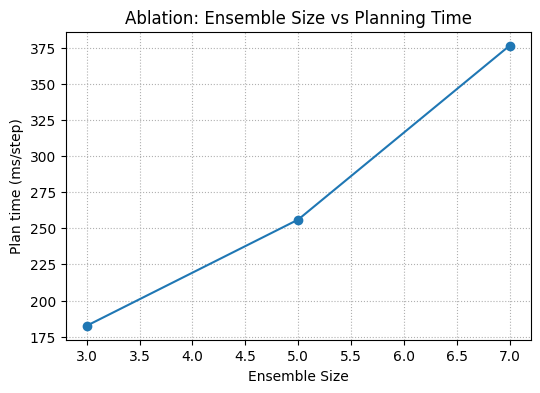

In [20]:
results=[]
for n in [3,5,7]:
    print(f"\n[ABLATION] Ensemble size={n}")
    ens_n = EnsembleModel(obs_dim, act_dim, n=n, device=device)
    # hızlı fine-tune: 10 epoch (tam eğitim çok uzun olabilir)
    for ep in range(10):
        for s,a,y,_ in train_loader:
            s=s.to(device); a=a.to(device); y=y.to(device)
            _ = ens_n.train_step(s,a,y)
    # obtain action-space info and pass act_dim to CEMPlanner (was missing)
    tmp_env = gym.make(ENV_ID)
    act_low  = tmp_env.action_space.low
    act_high = tmp_env.action_space.high
    act_dim_local = tmp_env.action_space.shape[0]
    tmp_env.close()
    planner = CEMPlanner(ens_n, act_low, act_high, act_dim_local, horizon=15, pop_size=1000, iters=4, device=device)
    env = boot.make_env(monitor=False)
    plan_times=[]; ret=0.0
    obs,_ = env.reset(seed=SEED+99)
    for t in range(200):
        t0 = time.perf_counter(); a = planner.act(obs); plan_times.append((time.perf_counter()-t0)*1000.0)
        obs,r,done,trunc,_ = env.step(a); ret += r
        if done or trunc: break
    env.close()
    results.append({'ens':n, 'return':ret, 'plan_ms_mean':float(np.mean(plan_times))})
    SummaryWriter(CEM_LOG).add_scalar(f'ablation/plan_ms_mean_n{n}', float(np.mean(plan_times)), 0)

df_res = pd.DataFrame(results)
display(df_res)
plt.figure(figsize=(6,4)); plt.plot(df_res['ens'], df_res['plan_ms_mean'], '-o'); plt.xlabel('Ensemble Size'); plt.ylabel('Plan time (ms/step)'); plt.title('Ablation: Ensemble Size vs Planning Time'); plt.grid(True, linestyle=':'); plt.show()

## 10) Pygame Render — CEM & PPO (ESC ile kapanır)

In [3]:
# %pip install pygame  # gerekirse
import numpy as np, pygame
def _make_rgb_env(env_id=ENV_ID, seed=SEED):
    env = gym.make(env_id, render_mode='rgb_array'); obs, info = env.reset(seed=seed); return env, obs
def _pygame_init(width, height, title='RL Demo'):
    pygame.init(); surf = pygame.display.set_mode((width, height)); pygame.display.set_caption(title); clock = pygame.time.Clock(); return surf, clock
def _pygame_frame(surf, frame):
    frame = np.ascontiguousarray(frame); h,w = frame.shape[:2]
    pg_surface = pygame.image.frombuffer(frame.tobytes(), (w,h), 'RGB'); surf.blit(pg_surface,(0,0)); pygame.display.flip()
def _handle_events():
    for event in pygame.event.get():
        if event.type == pygame.QUIT: return True
        if event.type == pygame.KEYDOWN and event.key == pygame.K_ESCAPE: return True
    return False
def render_demo(policy='CEM', episodes=2, max_steps=500, fps=30):
    assert policy in ['CEM','PPO']
    env, obs = _make_rgb_env(); first=env.render(); H,W = first.shape[0], first.shape[1]
    surf, clock = _pygame_init(W,H, title=f'{policy} Demo — {ENV_ID}')
    # query full action-space info (low/high and dim) and use act_dim when constructing CEMPlanner
    tmp = gym.make(ENV_ID)
    low = tmp.action_space.low
    high = tmp.action_space.high
    act_dim_local = tmp.action_space.shape[0]
    tmp.close()
    if policy=='CEM':
        planner = CEMPlanner(ens, low, high, act_dim_local, horizon=15, pop_size=1000, iters=5, device=device)
        def act_fn(s): return planner.act(s)
    else:
        def act_fn(s):
            a,_ = ppo.predict(s, deterministic=True); return a
    try:
        for ep in range(episodes):
            obs,_ = env.reset(seed=SEED+200+ep); ret=0.0
            for t in range(max_steps):
                if _handle_events(): print('[INFO] Demo kapandı.'); return
                a = act_fn(obs); obs,r,done,trunc,_ = env.step(a); ret += r
                frame = env.render(); _pygame_frame(surf, frame); clock.tick(fps)
                if done or trunc: break
            print(f'[{policy} DEMO] Episode {ep+1}/{episodes} return={ret:.1f}')
    finally:
        pygame.quit(); env.close()

# Örnek:
#render_demo(policy='CEM', episodes=2, max_steps=400, fps=30)
render_demo(policy='PPO', episodes=2, max_steps=400, fps=30)

NameError: name 'gym' is not defined

## 11) TensorBoard Grafikleri (kısa okuma yardımcıları)

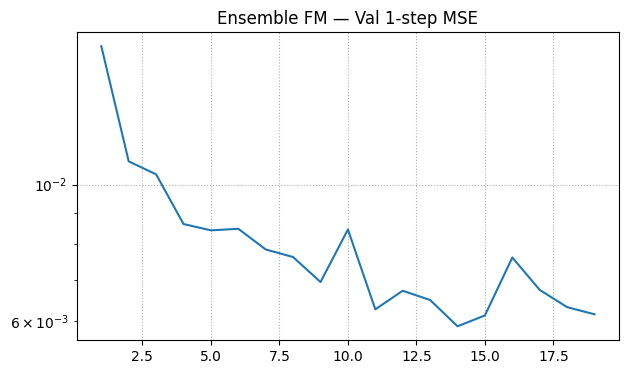

In [22]:
def tb_series(run_dir, tag):
    files=[]
    for root,_,fs in os.walk(run_dir):
        for f in fs:
            if f.startswith('events.out.tfevents'): files.append(os.path.join(root,f))
    if not files: return None
    dfs=[]
    for f in files:
        try:
            acc = ea.EventAccumulator(f, size_guidance={'scalars': 10**7}); acc.Reload()
            if tag in acc.Tags().get('scalars', []):
                s = acc.Scalars(tag)
                dfs.append(pd.DataFrame({'step':[i.step for i in s], 'val':[i.value for i in s]}))
        except Exception as e:
            print('[WARN] TB okunamadı:', f, e)
    if not dfs: return None
    df = pd.concat(dfs).groupby('step', as_index=False)['val'].mean().sort_values('step')
    return df

# Örnek kullanım: FM MSE trendi
df1 = tb_series(FM_LOG, 'val/1step_mse')
if df1 is not None:
    plt.figure(figsize=(7,4)); plt.plot(df1.step, df1.val); plt.yscale('log'); plt.title('Ensemble FM — Val 1-step MSE'); plt.grid(True, linestyle=':'); plt.show()

## 12) Meta Bilgi

In [ ]:
meta = dict(phase=PHASE, notebook=NOTEBOOK, step=STEP, env=ENV_ID, seed=SEED,
            root_dir=boot.root_dir, run_id=boot.run_id,
            ensemble_log=FM_LOG, cem_log=CEM_LOG, data_log=DATA_LOG, base_log=BASE_LOG,
            ckpt_ensemble=CKPT_ENSEMBLE_DIR, ckpt_cem=CKPT_CEM_DIR, ckpt_base=CKPT_BASE_DIR)
with open(os.path.join(boot.root_dir, 'meta.json'), 'w') as f: json.dump(meta, f, indent=2)
print(json.dumps(meta, indent=2))